# Datathon Passos Mágicos - Análise Exploratória e Storytelling

Este notebook responde às 11 perguntas do desafio com base na base consolidada analítica e, quando necessário, na base reduzida para modelagem.

## Objetivos
- Entender a evolução dos indicadores pedagógicos, psicossociais e de engajamento;
- Identificar padrões de risco de defasagem;
- Avaliar a efetividade do programa ao longo dos anos e fases;
- Preparar insumos para o modelo preditivo e para o storytelling da apresentação final.

## Bases utilizadas
- Base analítica consolidada: `base_PEDE_consolidada_analitica.parquet`
- Base reduzida para ML: `base_processada_reduzida_ML.parquet`

In [2]:
# 2) Imports e configuraçãoimport warnings
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
    RocCurveDisplay
)
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.ensemble import RandomForestClassifier

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 200)

sns.set_theme(style="whitegrid")

In [3]:
# 3) Carga das bases
df = pd.read_parquet("../data/processed/base_PEDE_consolidada_analitica.parquet")
df_ml = pd.read_parquet("../data/processed/base_processada_reduzida_ML.parquet")

print("Base analítica:", df.shape)
print("Base ML:", df_ml.shape)

display(df.head())
display(df_ml.head())


Base analítica: (3030, 55)
Base ML: (3030, 16)


,ano_pede,ra,fase,turma,nome,ano_nasc,data_nasc,idade,genero,ano_ingresso,instituicao_ensino,escola,ativo_inativo,pedra_2020,pedra_2021,pedra_2022,pedra_2023,pedra_2024,inde_2022,inde_2023,inde_2024,cg,cf,ct,n_av,avaliador_1,rec_av1,avaliador_2,rec_av2,avaliador_3,rec_av3,avaliador_4,rec_av4,avaliador_5,rec_av5,avaliador_6,rec_av6,iaa,ieg,ips,ipp,rec_psicologia,ida,mat,por,ing,indicado,atingiu_pv,ipv,ian,fase_ideal,defasagem,destaque_ieg,destaque_ida,destaque_ipv
0,2022,RA-1,7,A,Aluno-1,2003.0,NaT,19.0,Menina,2016,Escola Pública,<NA>,<NA>,Ametista,Ametista,Quartzo,<NA>,<NA>,5.783,NaN,NaN,753.0,18.0,10.0,4.0,Avaliador-5,Mantido na Fase atual,Avaliador-27,Promovido de Fase + Bolsa,Avaliador-28,Promovido de Fase,Avaliador-31,Mantido na Fase atual,None,None,None,None,8.3,4.1,5.6,NaN,Requer avaliação,4.0,2.7,3.5,6.0,Sim,Não,7.278,5.0,Fase 8 (Universitários),-1,Melhorar: Melhorar a sua entrega de lições de ...,Melhorar: Empenhar-se mais nas aulas e avaliaç...,Melhorar: Integrar-se mais aos Princípios Pass...
1,2022,RA-2,7,A,Aluno-2,2005.0,NaT,17.0,Menina,2017,Rede Decisão,<NA>,<NA>,Ametista,Ametista,Ametista,<NA>,<NA>,7.055,NaN,NaN,469.0,8.0,3.0,4.0,Avaliador-5,Promovido de Fase,Avaliador-27,Promovido de Fase + Bolsa,Avaliador-28,Promovido de Fase,Avaliador-31,Promovido de Fase + Bolsa,None,None,None,None,8.8,5.2,6.3,NaN,Sem limitações,6.8,6.3,4.5,9.7,Não,Não,6.778,10.0,Fase 7 (3º EM),0,Melhorar: Melhorar a sua entrega de lições de ...,Melhorar: Empenhar-se mais nas aulas e avaliaç...,Melhorar: Integrar-se mais aos Princípios Pass...
2,2022,RA-3,7,A,Aluno-3,2005.0,NaT,17.0,Menina,2016,Rede Decisão,<NA>,<NA>,Ametista,Ametista,Ágata,<NA>,<NA>,6.591,NaN,NaN,629.0,13.0,6.0,4.0,Avaliador-5,Promovido de Fase,Avaliador-27,Promovido de Fase + Bolsa,Avaliador-28,Promovido de Fase + Bolsa,Avaliador-31,Promovido de Fase + Bolsa,None,None,None,None,0.0,7.9,5.6,NaN,Sem limitações,5.6,5.8,4.0,6.9,Não,Não,7.556,10.0,Fase 7 (3º EM),0,Destaque: A sua boa entrega das lições de casa.,Melhorar: Empenhar-se mais nas aulas e avaliaç...,Destaque: A sua boa integração aos Princípios ...
3,2022,RA-4,7,A,Aluno-4,2005.0,NaT,17.0,Menino,2017,Rede Decisão,<NA>,<NA>,Ametista,Ametista,Quartzo,<NA>,<NA>,5.951,NaN,NaN,731.0,15.0,7.0,4.0,Avaliador-5,Promovido de Fase,Avaliador-27,Mantido na Fase atual,Avaliador-28,Mantido na Fase atual,Avaliador-31,Mantido na Fase atual,None,None,None,None,8.8,4.5,5.6,NaN,Requer avaliação,5.0,2.8,3.5,8.7,Não,Não,5.278,10.0,Fase 7 (3º EM),0,Melhorar: Melhorar a sua entrega de lições de ...,Melhorar: Empenhar-se mais nas aulas e avaliaç...,Melhorar: Integrar-se mais aos Princípios Pass...
4,2022,RA-5,7,A,Aluno-5,2005.0,NaT,17.0,Menina,2016,Rede Decisão,<NA>,<NA>,Ametista,Ametista,Ametista,<NA>,<NA>,7.427,NaN,NaN,344.0,6.0,2.0,4.0,Avaliador-5,Promovido de Fase,Avaliador-27,Promovido de Fase + Bolsa,Avaliador-28,Promovido de Fase + Bolsa,Avaliador-31,Promovido de Fase + Bolsa,None,None,None,None,7.9,8.6,5.6,NaN,Requer avaliação,5.2,7.0,2.9,5.7,Não,Não,7.389,10.0,Fase 7 (3º EM),0,Destaque: A sua boa entrega das lições de casa.,Melhorar: Empenhar-se mais nas aulas e avaliaç...,Melhorar: Integrar-se mais aos Princípios Pass...


,ano_pede,inde,n_av,iaa,ieg,ips,ipp,ida,mat,por,ing,ipv,ian,fase_ideal,defasagem,risco_defasagem_atual
0,2022,5.783,4.0,8.3,4.1,5.6,NaN,4.0,2.7,3.5,6.0,7.278,5.0,Fase 8 (Universitários),-1,0
1,2022,7.055,4.0,8.8,5.2,6.3,NaN,6.8,6.3,4.5,9.7,6.778,10.0,Fase 7 (3º EM),0,0
2,2022,6.591,4.0,0.0,7.9,5.6,NaN,5.6,5.8,4.0,6.9,7.556,10.0,Fase 7 (3º EM),0,0
3,2022,5.951,4.0,8.8,4.5,5.6,NaN,5.0,2.8,3.5,8.7,5.278,10.0,Fase 7 (3º EM),0,0
4,2022,7.427,4.0,7.9,8.6,5.6,NaN,5.2,7.0,2.9,5.7,7.389,10.0,Fase 7 (3º EM),0,0


In [4]:
# 4) Padronizações auxiliares
# cria coluna inde única na base analítica
df["inde"] = np.nan

if "inde_2022" in df.columns:
    df.loc[df["ano_pede"] == 2022, "inde"] = df["inde_2022"]
if "inde_2023" in df.columns:
    df.loc[df["ano_pede"] == 2023, "inde"] = df["inde_2023"]
if "inde_2024" in df.columns:
    df.loc[df["ano_pede"] == 2024, "inde"] = df["inde_2024"]

# garantir numéricos
cols_numericas = [
    "idade", "ano_ingresso", "inde", "iaa", "ieg", "ips", "ipp",
    "ida", "mat", "por", "ing", "ipv", "ian", "defasagem"
]

for col in cols_numericas:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors="coerce")

# categorias úteis
for col in ["fase", "turma", "genero", "instituicao_ensino", "pedra_2022", "pedra_2023", "pedra_2024"]:
    if col in df.columns:
        df[col] = df[col].astype("string").str.strip()

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3030 entries, 0 to 3029
Data columns (total 56 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   ano_pede            3030 non-null   int64         
 1   ra                  3030 non-null   string        
 2   fase                3030 non-null   string        
 3   turma               3030 non-null   string        
 4   nome                3030 non-null   string        
 5   ano_nasc            860 non-null    float64       
 6   data_nasc           2170 non-null   datetime64[ns]
 7   idade               2631 non-null   float64       
 8   genero              3030 non-null   string        
 9   ano_ingresso        3030 non-null   int64         
 10  instituicao_ensino  3029 non-null   string        
 11  escola              1155 non-null   string        
 12  ativo_inativo       0 non-null      string        
 13  pedra_2020          754 non-null    string      

In [5]:
# 5) Funções auxiliares
def plot_bar(data, x, y, title, figsize=(10,5), rotation=0):
    plt.figure(figsize=figsize)
    sns.barplot(data=data, x=x, y=y)
    plt.title(title)
    plt.xticks(rotation=rotation)
    plt.tight_layout()
    plt.show()


def plot_line(data, x, y, hue=None, title="", figsize=(10,5), rotation=0, marker="o"):
    plt.figure(figsize=figsize)
    sns.lineplot(data=data, x=x, y=y, hue=hue, marker=marker)
    plt.title(title)
    plt.xticks(rotation=rotation)
    plt.tight_layout()
    plt.show()


def plot_heatmap_corr(df_corr, title="Mapa de Correlação"):
    plt.figure(figsize=(10, 7))
    sns.heatmap(df_corr, annot=True, cmap="Blues", fmt=".2f")
    plt.title(title)
    plt.tight_layout()
    plt.show()


def categorizar_defasagem(valor):
    if pd.isna(valor):
        return "Sem informação"
    if valor <= 0:
        return "Sem defasagem"
    elif valor == 1:
        return "Defasagem leve"
    elif valor == 2:
        return "Defasagem moderada"
    else:
        return "Defasagem severa"

### 4. Autoavaliação (IAA)

,iaa,ida,ieg
iaa,1.000000,0.115241,0.133078
ida,0.115241,1.000000,0.539057
ieg,0.133078,0.539057,1.000000


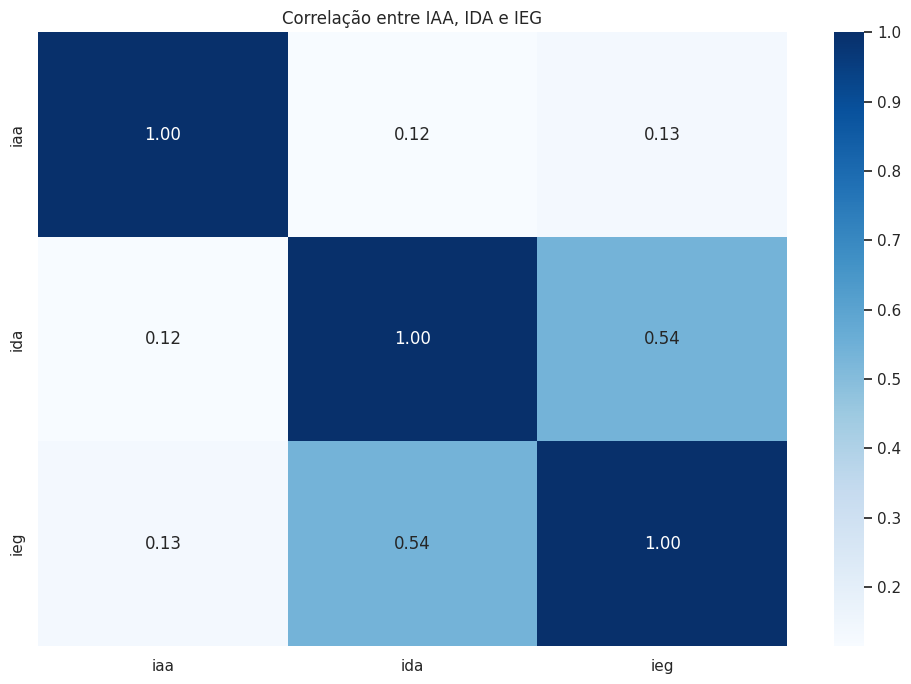

In [6]:
# 19) Correlação entre IAA, IDA e IEG
corr_cols = [c for c in ["iaa", "ida", "ieg"] if c in df.columns]
corr_iaa = df[corr_cols].corr()
display(corr_iaa)

plot_heatmap_corr(corr_iaa, "Correlação entre IAA, IDA e IEG")

In [7]:
# 20) Diferença entre percepção e desempenho
# padronização simples para comparar escalas
df["iaa_z"] = (df["iaa"] - df["iaa"].mean()) / df["iaa"].std()
df["ida_z"] = (df["ida"] - df["ida"].mean()) / df["ida"].std()

df["gap_autoavaliacao_desempenho"] = df["iaa_z"] - df["ida_z"]

display(
    df[["iaa", "ida", "ieg", "gap_autoavaliacao_desempenho"]]
    .describe()
)

,iaa,ida,ieg,gap_autoavaliacao_desempenho
count,2865.000000,2852.000000,2954.000000,2851.000000
mean,7.918225,6.375964,7.945696,0.004078
std,2.626209,1.956637,2.152281,1.327488
min,0.000000,0.000000,0.000000,-4.816146
25%,7.900000,5.100000,7.300000,-0.674526
50%,8.751000,6.666667,8.600000,0.027830
75%,9.500000,7.833333,9.400000,0.831516
max,10.002000,10.000000,10.000000,3.899016


,perfil,qtd
0,Percepção coerente,1003
1,Superestima desempenho,973
2,Subestima desempenho,875
3,Sem informação,179


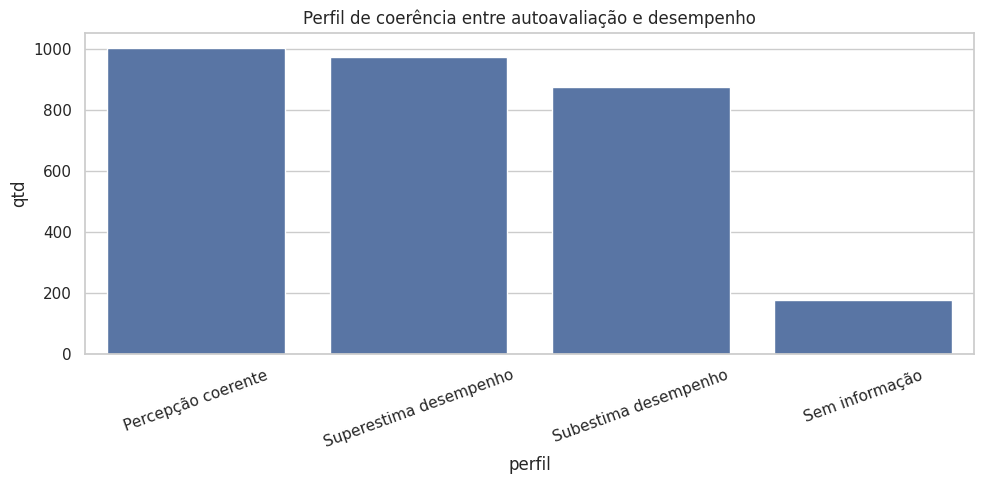

In [8]:
# 21) Casos de superestimação e subestimação
def classificar_gap(v):
    if pd.isna(v):
        return "Sem informação"
    if v > 0.5:
        return "Superestima desempenho"
    elif v < -0.5:
        return "Subestima desempenho"
    return "Percepção coerente"

df["perfil_autoavaliacao"] = df["gap_autoavaliacao_desempenho"].apply(classificar_gap)

perfil_auto = (
    df["perfil_autoavaliacao"]
    .value_counts()
    .rename_axis("perfil")
    .reset_index(name="qtd")
)

display(perfil_auto)

plot_bar(
    perfil_auto,
    x="perfil",
    y="qtd",
    title="Perfil de coerência entre autoavaliação e desempenho",
    rotation=20
)

### Leitura analítica
- Quando IAA e IDA caminham juntos, a percepção do aluno tende a ser coerente com o desempenho.
- Casos de superestimação podem indicar baixa consciência do próprio aprendizado.
- Casos de subestimação podem indicar baixa autoconfiança, mesmo em alunos com desempenho razoável.